# Глава 5. SARIMAX


## 1. Теория

### 1.1 Идея SARIMAX

**SARIMAX** = **S**easonal **A**uto**R**egressive **I**ntegrated **M**oving **A**verage with e**X**ogenous factors. Записывается как `SARIMAX(p,d,q)(P,D,Q,s)`. - Модель учитывает оба источника предсказательной силы одновременно, потому что в реальных данных они обычно присутствуют независимо друг от друга:
- Несезонная часть `(p,d,q)` — про «соседей» по времени: вчера, позавчера. Отвечает на вопрос «если вчера было много заказов, поможет ли это предсказать сегодня — независимо от того, какой сегодня день недели?» (инерция, импульс).
    - `p (AR)` — порядок несезонной авторегрессии: прогноз = взвешенная сумма **фактических** значений вчера/позавчера;
    - `d (I)` — порядок несезонного дифференцирования: сколько раз берём разность `y[t] - y[t-1]`, чтобы убрать тренд;
    - `q (MA)` — порядок несезонного скользящего среднего: прогноз = поправка на то, насколько модель **ошиблась** вчера/позавчера;
- Сезонная часть (`P,D,Q,s`) — про «двойников» из других циклов: тот же день недели, но неделю-две назад. Отвечает на вопрос «помогает ли предсказать пятницу прошлая пятница, независимо от того, что было в четверг перед ней?» (недельный ритм).
    - `P` — то же самое, что `p (AR)`, только для той же точки цикла (например, того же дня недели) `s` шагов назад, а не для вчера;
    - `D` — то же самое, что `d (I)`, только считает разность с той же точкой прошлого цикла — `y[t] - y[t-s]`, а не со вчера — убирает сезонность, а не тренд;
    - `Q` — то же самое, что `q (MA)`, только поправка на ошибку в той же точке прошлого цикла, а не вчера;
    - `s` — периодичность (длина полного сезонного цикла), например `7` для недельной сезонности на дневных данных, `12` — для годовой на месячных.

В отличие от `NaiveModel`/`MovingAverageModel`/`SeasonalMovingAverageModel`, здесь нет единой формулы «прогноз = среднее из точек» — SARIMAX реально **оценивает параметры** линейной модели по данным (методом максимального правдоподобия), а не просто усредняет прошлое.

Буква `I` (Integrated) — это как раз дифференцирование: модель сама приводит ряд к стационарному виду внутри себя по параметрам $d$/$D$, тебе не нужно вручную дифференцировать данные и подавать модели уже дифференцированный ряд.

### 1.2 Параметры и реализация

Исходник `etna/models/sarimax.py`, класс `SARIMAXModel` (сигнатура сокращена):

```python
class SARIMAXModel(PerSegmentModelMixin, ...):
    def __init__(
        self,
        order: Tuple[int, int, int] = (1, 0, 0),
        seasonal_order: Tuple[int, int, int, int] = (0, 0, 0, 0),
        trend: Optional[str] = None,
        ...
    ):
```

**Параметры `SARIMAXModel`:**
- `order` *(по умолчанию `(1, 0, 0)`)* — кортеж $(p, d, q)$.
- `seasonal_order` *(по умолчанию `(0, 0, 0, 0)`)* — кортеж $(P, D, Q, s)$; по умолчанию сезонность выключена ($s=0$).
- `trend` — детерминированный тренд-полином (`'c'` — константа, `'t'` — линейный тренд по времени, `'ct'` — оба); по умолчанию не используется.

**В отличие от `SeasonalMovingAverageModel` (и всей её семьи):**
- нет `context_size`/`window`/`seasonality` в прежнем смысле — вместо готовой формулы усреднения модель **обучается**: `fit()` здесь впервые не пустышка, а реальная MLE-оптимизация параметров (метод максимального правдоподобия - общий статистический способ находить числовые параметры модели по данным, когда сами параметры заранее неизвестны);
- обучение идёт **отдельно по каждому сегменту** (`PerSegmentModelMixin`) — по сути под капотом на каждый юнит создаётся своя независимая `statsmodels`-модель;
- `make_future`/`forecast` вызываются проще — без `tail_steps` и `prediction_size`: `train_ts.make_future(HORIZON)` и `model.forecast(future_ts)`. Модель сама хранит нужное внутреннее состояние;
- умеет использовать экзогенные регрессоры (буква `X` в названии) — первая модель в серии с такой возможностью; в этой главе их не используем, но держим в уме на будущее.


### 1.3 Особенности

- **Что такое дифференцирование — на пальцах.** Это просто вычитание: `y[t] - y[t-1]` (обычное) или `y[t] - y[t-s]` (сезонное, с шагом `s`). Вместо самих значений ряда смотрим на то, насколько они изменились по сравнению с предыдущей точкой (или с той же точкой прошлого цикла). Тренд и сезонность в этих *изменениях* обычно намного слабее, чем в самих значениях — поэтому такая простая операция превращает нестационарный ряд в стационарный. `d`/`D` — это просто «сколько раз подряд применили эту операцию» (обычную/сезонную соответственно).
- **Кто дифференцирует, а кто подбирает числа.** Сам ряд дифференцирует **модель**, внутри `fit()`/`forecast()`, по параметрам `d`/`D` — тебе не нужно вручную дифференцировать данные и скармливать ей результат: в `train_ts`/`future_ts` всегда идёт оригинальный, недифференцированный ряд. А вот сами числа `d`, `D`, `s` модель не знает и не подбирает — их нужно определить заранее, руками, на **отдельной копии** ряда: тестом Дики-Фуллера (`adfuller`, p-value < 0.05 → ряд стационарен) проверяешь, стал ли ряд стационарным, а `plot_acf` подсказывает период `s` (пики на кратных лагах). Это разведка перед запуском модели, а не подготовка данных для неё.
- **Не переусердствуй с дифференцированием.** Лишний шаг дифференцирования не обязательно улучшает ситуацию, даже если ряд уже стационарен — это легко проверить самому, посчитав `adfuller` до и после лишнего `.diff(1)` (см. Задание 1 и Задание 3).
- **Медленнее, чем всё, что было раньше.** `fit()` — это реальная оптимизация, а не константное время; на наших объёмах данных (сотни точек, до 10 сегментов) всё ещё доли секунды, но это принципиально другой порядок работы, чем у моделей из прошлых глав.

## 2. Данные

Те же файлы, что и в предыдущих тетрадях (`local/data/`, в `.gitignore`):
- `units.csv` — 10 юнитов; для основной практики берём 2 из них (размер `10+`, typical + busier), для бонуса — все 10.
- `facts-by-date.csv` — дневные факты, 2022-01-01…2026-08-31.

В этой главе не сравниваем с продовым прогнозом (`forecasts-by-date.csv`) — это отдельная тема, которой займёшься сам.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from etna.datasets import TSDataset, generate_periodic_df
from etna.models import SARIMAXModel, SeasonalMovingAverageModel, MovingAverageModel, NaiveModel
from etna.metrics import SMAPE, WAPE, MAPE, MAE
from etna.analysis import plot_forecast

from src.custom_logger import log_to_mlflow
from src.prod_metrics import bias, pooled

DATA_DIR = "../../local/data"


/Users/skv/projects-skv/study-etna/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Практика

От простого к сложному: сначала на синтетике превращаем нестационарный ряд в стационарный руками, потом повторяем то же самое на реальном юните и подбираем параметры, потом обучаем SARIMAX и сравниваем с предыдущими моделями.


### Задание 1. Синтетика: делаем ряд стационарным дифференцированием

1. Собери синтетический ряд, у которого есть **и** тренд, **и** недельная сезонность одновременно (например, недельный паттерн, как в прошлой главе, плюс линейный тренд поверх, как в главе про `MovingAverageModel` — объедини оба приёма). Добавь немного шума (`np.random.normal`) — на полностью чистом сигнале `diff()` может выродиться в константу, и `adfuller` откажется считать тест.
2. Проверь стационарность тестом `adfuller` — сформулируй нулевую гипотезу своими словами (раздел 1.3) и посмотри на `p-value`. Ожидаемо ли, что ряд нестационарен?
3. Убери сезонность сезонным дифференцированием (`series.diff(periods=7)`), проверь `adfuller` снова.
4. Добавь ещё дифференцирование первого порядка (`.diff(1)`) поверх сезонного, проверь `adfuller` в третий раз — стало ли значимо лучше, или ряд был готов уже после шага 3?
5. На каждом шаге строй график ряда — глазами убедись, что тренд/сезонность визуально исчезают по мере дифференцирования.


In [15]:
def get_stattest(series, alpha=0.05):
    """Тест Дики-Фуллера - это статистический метод для проверки временного ряда на стационарность путем определения наличия в нем единичного корня.
    Нулевая гипотеза (H₀): Ряд нестационарен (содержит единичный корень, параметры равны нулю).
    Альтернативная гипотеза (H₁): Ряд стационарен (единичного корня нет)

    :param series:
    :return:
    """
    result = adfuller(series)
    p_val = result[1]

    if p_val >= alpha:
        print(
            f"p_value: {p_val}\n"
            f"Не можем отклонить нулевую гипотезу о том, что ряд нестациорнаный"
        )

    else:
        print(
            f"p_value: {p_val}\n"
            f"Можем отклонить нулевую гипотезу о том, что ряд нестациорнаный"
        )

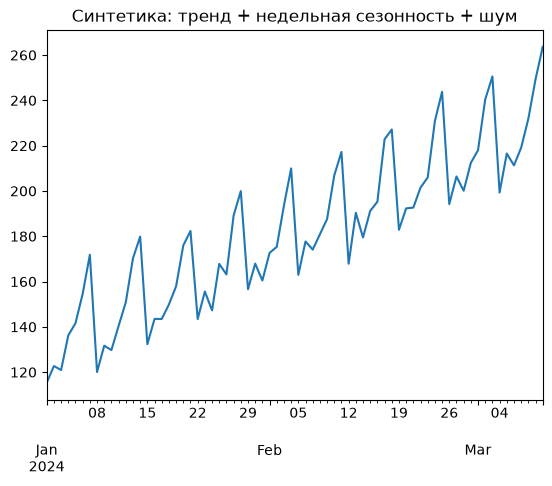

In [6]:
# Синтетика: тренд + недельная сезонность + немного шума (иначе diff() выродится в константу)
np.random.seed(0)
periods = 70

day_of_week_pattern = np.array([10, 20, 15, 25, 30, 50, 60], dtype=float)
seasonal = np.tile(day_of_week_pattern, periods // 7 + 1)[:periods]
trend = np.arange(periods) * 1.5
noise = np.random.normal(0, 3, periods)

series = pd.Series(
    seasonal + trend + 100 + noise,
    index=pd.date_range("2024-01-01", periods=periods, freq="D"),
)
series.plot(title="Синтетика: тренд + недельная сезонность + шум");

In [7]:
# 1. Исходный ряд — ожидаемо нестационарный: есть и тренд, и сезонность
get_stattest(series)

p_value: 0.983926821371645
Не можем отклонить нулевую гипотезу о том, что ряд нестациорнаный


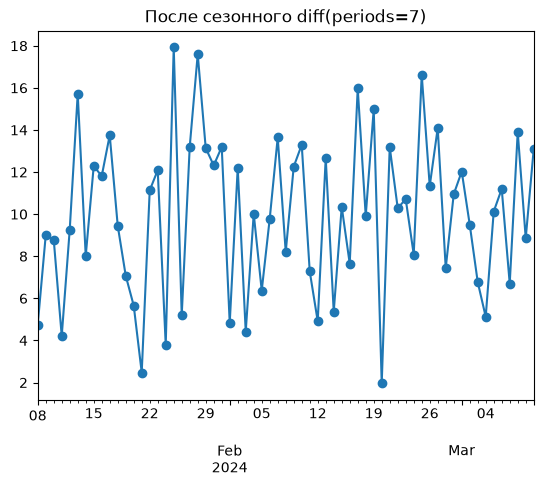

In [9]:
# 2. Убираем сезонность сезонным дифференцированием (periods=7)

# Сравниваем сегодняшнее значение с тем же днём прошлой недели (шаг ровно 7 дней, наш период).
# Если в ряде есть повторяющийся недельный узор (понедельники похожи на понедельники), эта разница его убирает.
# Недельный паттерн вычитается сам из себя.
# Это и есть сезонное дифференцирование (D).
series_diff_seasonal = series.diff(periods=7).dropna()
series_diff_seasonal.plot(marker="o", title="После сезонного diff(periods=7)");

In [10]:
get_stattest(series_diff_seasonal)

p_value: 1.270228337541959e-05
Можем отклонить нулевую гипотезу о том, что ряд нестациорнаный


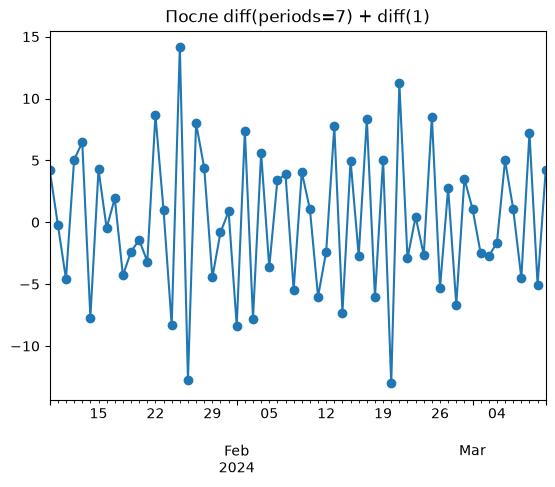

In [12]:
# 3. Добавляем обычное дифференцирование первого порядка поверх сезонного

# series.diff(1) — это y[t] - y[t-1]
# Сравниваем сегодня со вчера, шаг всегда 1, без привязки к периоду.
# Если в ряде есть тренд (плавный рост/падение уровня), день-ко-дню разница выходит примерно постоянной — тренд «съедается».
# Это обычное дифференцирование (d).
series_diff_seasonal_diff1 = series_diff_seasonal.diff(1).dropna()
series_diff_seasonal_diff1.plot(marker="o", title="После diff(periods=7) + diff(1)");

In [13]:
# стало ли значимо лучше, или ряд был готов уже после сезонного diff(7)?
get_stattest(series_diff_seasonal_diff1)

p_value: 4.8220083720916724e-05
Можем отклонить нулевую гипотезу о том, что ряд нестациорнаный


### Задание 2. Загрузи данные по 2 юнитам размера `10+`

1. Прочитай `facts-by-date.csv` и `units.csv`, оставь только 2 юнита размера `10+` (typical + busier) — так же, как для предыдущих моделей.
2. Собери `TSDataset` (дневная частота), где `segment` = `MaskedUnitId`.
3. Посмотри на `ts.describe()`.
4. Построй `ts.plot()`.


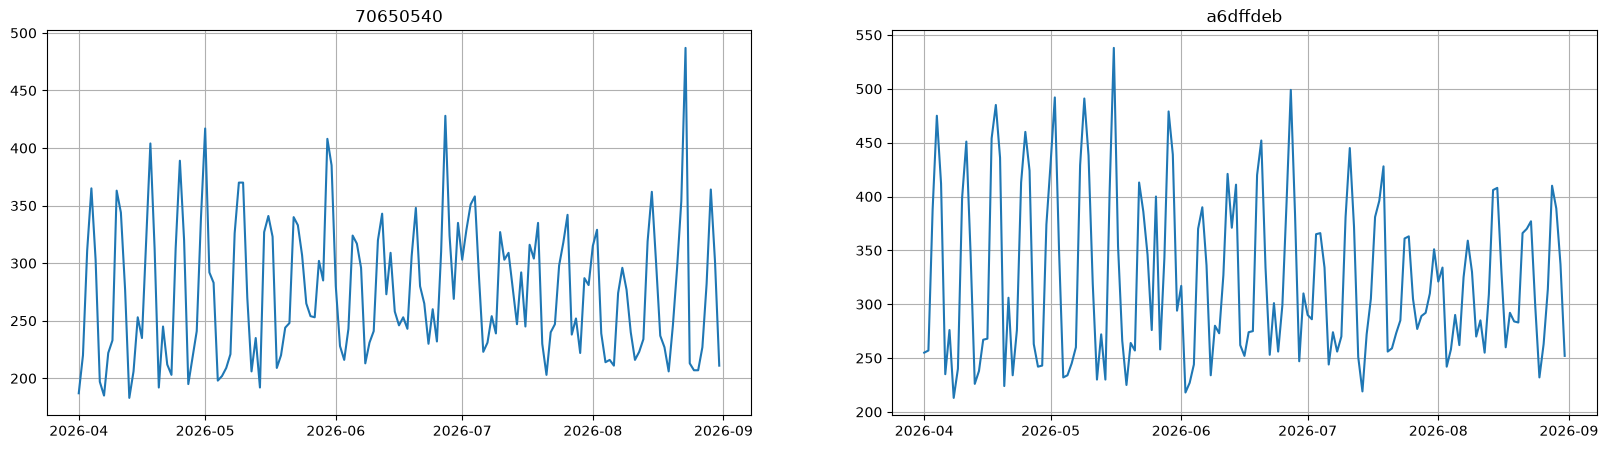

In [4]:
units_df = (pd
.read_csv(filepath_or_buffer=f"{DATA_DIR}/units.csv")
.rename(columns={
    "MaskedUnitId": "segment",
    "UnitSize": "unit_size",
    "PickReason": "pick_reason",
    "TotalOrders":"total_orders"
})
[["segment", "unit_size", "pick_reason", "total_orders"]]

)

orders_df = (
    pd.read_csv(f"{DATA_DIR}/facts-by-date.csv")
    .rename(columns={
        "CalendarDate": "timestamp",
        "MaskedUnitId": "segment",
        "Fact": "target",
    })
    [["timestamp", "segment", "target"]]
)

# Грязно выравниваем дату начала ряда, чтобы данные были по всем юнитам
orders_df = orders_df[orders_df['timestamp'] >= "2026-04-01"]
# Отбираем юниты
orders_sample_df = orders_df.merge(units_df[units_df["unit_size"] == "10+"]["segment"], how="inner", left_on="segment", right_on="segment", copy=True)

orders_sample_ts = TSDataset(orders_sample_df, freq="D")
orders_sample_ts.plot()

### Пошаговая схема подбора `(p, d, q), (P, D, Q, s)`

Цель — узнать эти 7 чисел для `SARIMAXModel`, не перебирая их вслепую.

1. Найди $\large s$ - периодичность (длина полного сезонного цикла). На **сыром** ряде ищи регулярно повторяющиеся пики на одинаковом шаге лагов (например, `7, 14, 21...`). Стационарность для этого шага не нужна — период виден и на нестационарном ряде. Делай это через `plot_acf()`
2. Сделай ряд стационарным — на отдельной копии, не трогая оригинал:
   - `get_stattest(series)` на сыром ряде.
        - Если нестационарен, то `.diff(periods=s).dropna()` → `get_stattest(...)` снова. Это будет сезонным дифференцированием.
        - Если нестационарен, то `.diff(1).dropna()` → `get_stattest(...)` снова. Это будет дифференцирование первого порядка поверх сезонного.
   - Если стало стационарно уже после сезонного дифференцирования, то не надо делать `.diff(1)`.
3. На стационарном ряде построить `plot_acf()` и `plot_pacf()` чтобы подобрать параметры для модели:
   - ACF, первые лаги → `q`; ACF, лаги, кратные `s` → `Q`.
   - PACF, первые лаги → `p`; PACF, лаги, кратные `s` → `P`.
4. Собери кандидатов: `order=(p, d, q)`, `seasonal_order=(P, D, Q, s)`.
5. Обучи модель на ОРИГИНАЛЬНОМ, нетронутом `train_ts` (не на диагностической продифференцированной копии!) — `SARIMAXModel` дифференцирует сама по `d`/`D`, ей нужны только числа, а не уже дифференцированные данные.

In [11]:
def plot_correlogram(series, func, lags=60, figsize=(20, 5), xtick_step=1):
    fig, ax = plt.subplots(figsize=figsize)
    func(series, lags=lags, ax=ax)
    ax.set_xticks(range(0, lags + 1, xtick_step))
    ax.tick_params(axis="x", labelsize=10)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Задание 3. Стационарность и подбор параметров на одном юните

Возьми один юнит (например, самый «busier» из размера `10+`) и пройди по шпаргалке выше шаг за шагом:

1. Шаг 1 шпаргалки — `plot_correlogram(series, func=plot_acf)` на сыром ряде юнита: найди `s`.
2. Шаг 2 шпаргалки — `get_stattest` → `.diff(periods=s)` → `get_stattest` → при необходимости `.diff(1)` → `get_stattest`. Зафиксируй, сколько раз продифференцировал — это `d` и `D`.
3. Шаг 3 шпаргалки — на финальном стационарном ряде: `plot_correlogram(..., func=plot_acf)` и `plot_correlogram(..., func=plot_pacf)`. Определи кандидатов `p`, `q`, `P`, `Q`.
4. Собери итоговые `order=(p,d,q)` и `seasonal_order=(P,D,Q,s)` — они понадобятся в Задании 4.


#### 70650540

In [53]:
HORIZON = 14

orders_unit_ts = TSDataset(df=orders_sample_ts[:, "70650540", :], freq=orders_sample_ts.freq)
train_ts, test_ts = orders_unit_ts.train_test_split(test_size=14)

train_series = train_ts[:, "70650540", "target"]

In [54]:
get_stattest(train_series)

p_value: 0.43124940348584795
Не можем отклонить нулевую гипотезу о том, что ряд нестациорнаный


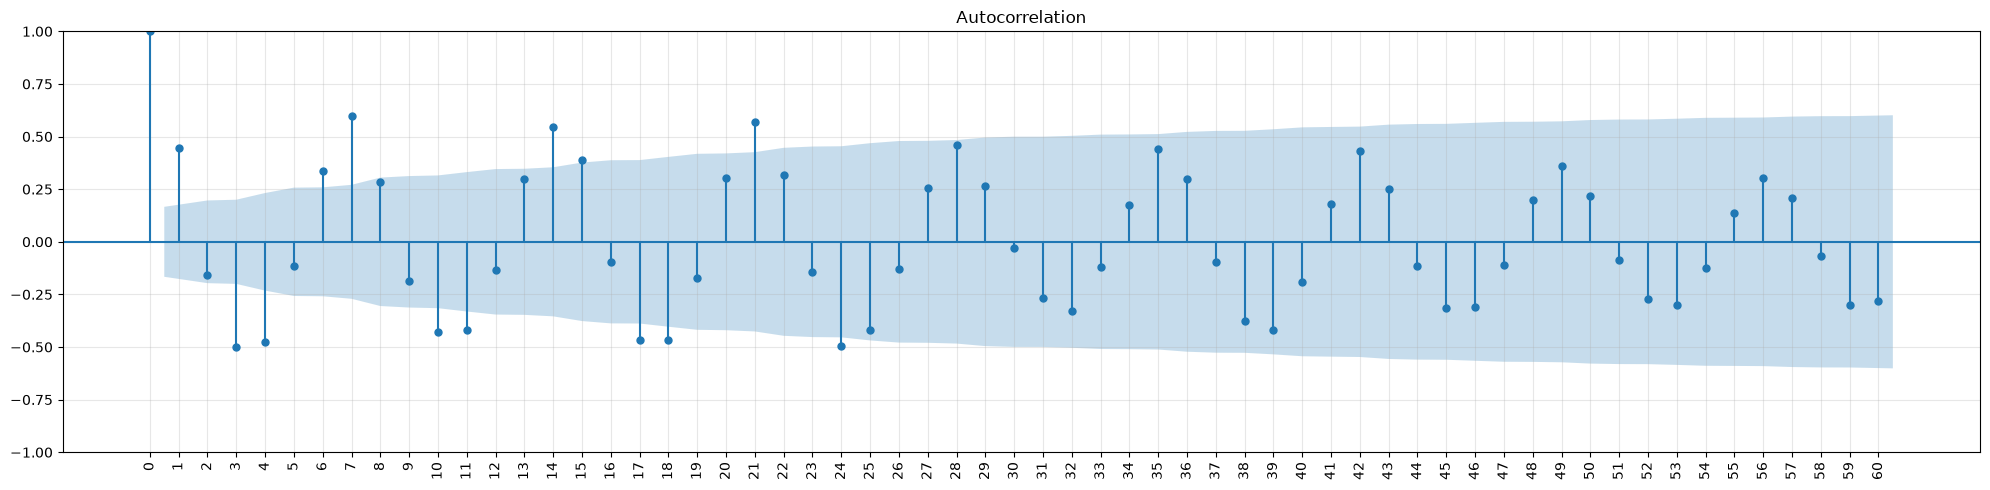

In [55]:
plot_correlogram(series=train_series, func=plot_acf)

In [56]:
train_series_diff = train_series.diff(periods=7).dropna()
get_stattest(train_series_diff)

p_value: 6.767460438409553e-07
Можем отклонить нулевую гипотезу о том, что ряд нестациорнаный


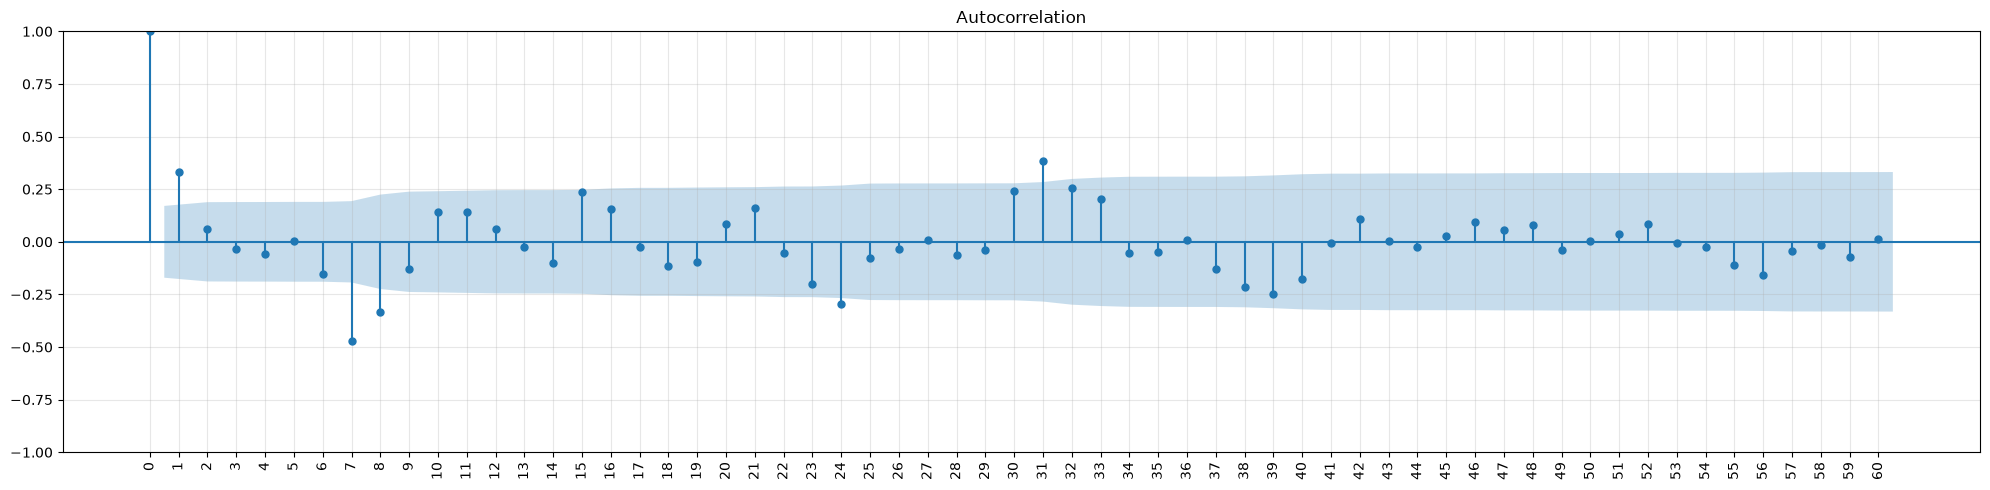

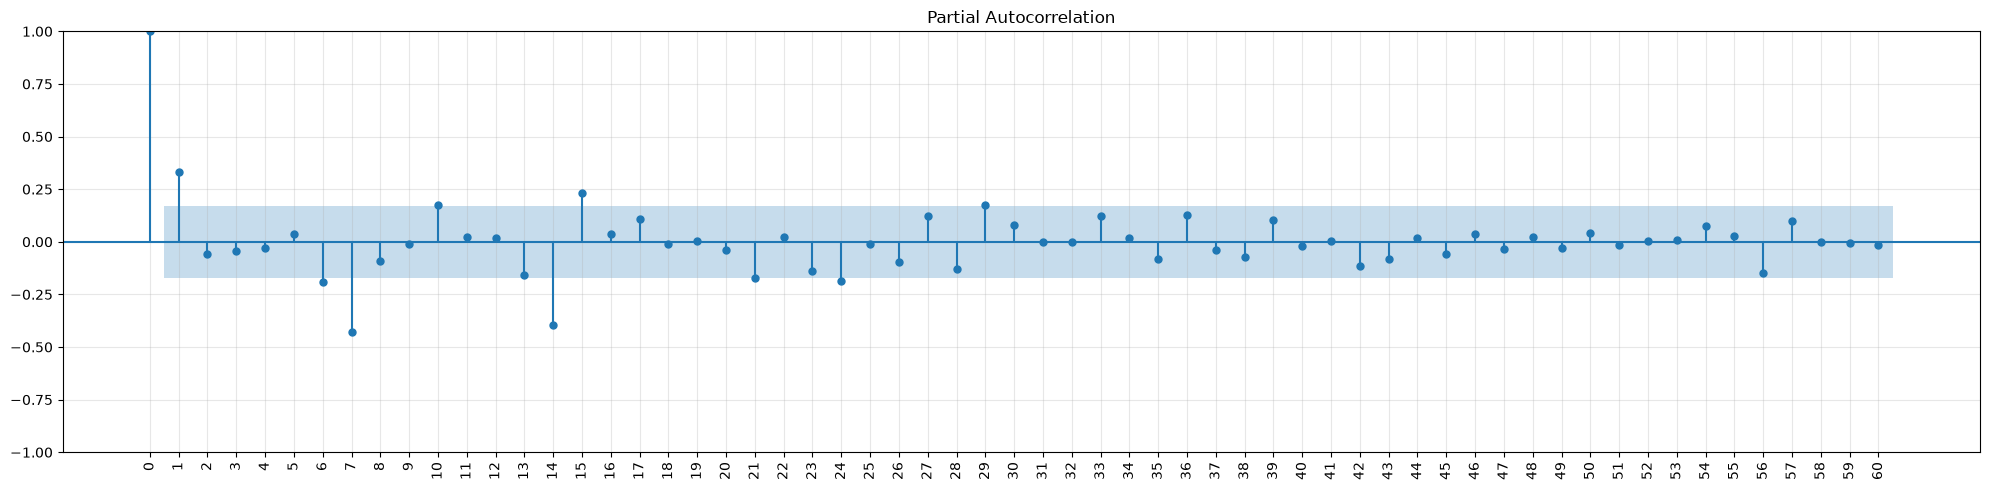

In [57]:
plot_correlogram(series=train_series_diff, func=plot_acf)
plot_correlogram(series=train_series_diff, func=plot_pacf)

In [62]:
MODEL_PARAMS = {
    # Основной кандидат: лучше всего совпадает с картиной ACF/PACF
    "first": {
        "order": (
            1,  # p — на PACF после diff(7) значим только лаг 1 (≈0.25), дальше обрыв → AR(1)
            0,  # d — ряд стал стационарным уже после сезонного diff(7) (ADF p < 0.05), обычный diff(1) не нужен
            0,  # q — корреляцию на лаге 1 уже объясняет AR(1) (p=1), отдельный MA не добавляем
        ),
        "seasonal_order": (
            0,  # P — на PACF сезонные лаги 7, 14, 21 плавно затухают, а не обрываются → это признак MA, а не AR
            1,  # D — сырой ряд нестационарен (ADF p ≈ 0.22), после одного diff(7) стационарен → одно сезонное дифференцирование
            1,  # Q — на ACF сильный пик на лаге 7 (≈−0.47), а на лаге 14 уже в пределах шума → обрыв после первого сезонного лага → сезонный MA(1)
            7,  # s — на ACF сырого ряда пики на лагах 7, 14, 21, 28… → недельный цикл
        ),
    },
    # Запасной кандидат: обратное толкование тех же графиков, для сравнения
    "second": {
        "order": (
            0,  # p — лаг 1 объясняем через MA, а не AR
            0,  # d — как в основном кандидате: хватает сезонного diff(7)
            1,  # q — на ACF после diff(7) значим только лаг 1, дальше обрыв → тоже можно читать как MA(1)
        ),
        "seasonal_order": (
            1,  # P — на PACF значим сезонный лаг 7 (≈−0.45) → пробуем сезонный AR(1) вместо MA
            1,  # D — как в основном кандидате: одно сезонное дифференцирование
            0,  # Q — сезонную связь берёт на себя P, Q не добавляем
            7,  # s — недельный цикл
        ),
    },
}

### Задание 4. Обучаем SARIMAX на одном юните

1. Собери `order=(p,d,q)` и `seasonal_order=(P,D,Q,s)` по наблюдениям из Задания 3 (не знаешь, с чего начать — попробуй что-то простое вроде `order=(1,1,1)`, `seasonal_order=(0,1,1,s)`).
2. `model = SARIMAXModel(order=..., seasonal_order=...)`, `model.fit(train_ts)`, `future_ts = train_ts.make_future(HORIZON)`, `forecast_ts = model.forecast(future_ts)` — заметь, насколько это короче, чем `tail_steps`/`prediction_size` у предыдущих моделей (раздел 1.2).
3. Посчитай `SMAPE`, визуализируй через `plot_forecast`.
4. Попробуй ещё 2-3 сочетания `order`/`seasonal_order` (в том числе дефолтное `order=(1,0,0)` без сезонности вообще) — сравни `SMAPE`. Насколько осознанный подбор параметров из Задания 3 лучше дефолта или случайного набора?


In [63]:
model_1 = SARIMAXModel(**MODEL_PARAMS["first"])
model_1.fit(train_ts)
future_1_ts = train_ts.make_future(future_steps=HORIZON)
forecast_1_ts = model_1.forecast(future_1_ts)
smape_1 = SMAPE()(y_true=test_ts, y_pred=forecast_1_ts)

In [64]:
model_2 = SARIMAXModel(**MODEL_PARAMS["second"])
model_2.fit(train_ts)
future_2_ts = train_ts.make_future(future_steps=HORIZON)
forecast_2_ts = model_2.forecast(future_2_ts)
smape_2 = SMAPE()(y_true=test_ts, y_pred=forecast_2_ts)

In [65]:
print(
    f"SMAPE_1 [first]: {smape_1}\n"
    f"SMAPE_2 [second]: {smape_2}"
)

SMAPE_1 [first]: {'70650540': 11.229827205693306}
SMAPE_2 [second]: {'70650540': 9.2206213917393}


### Задание 5. Общая картина по обоим юнитам

1. Обучи `SARIMAXModel` сразу на обоих сегментах для 2-3 сочетаний `order`/`seasonal_order`.
2. Посчитай `SMAPE` — per-segment и агрегированно (`mode="macro"`).
3. Сравни лучший результат с лучшими результатами `NaiveModel`, `MovingAverageModel` и `SeasonalMovingAverageModel` на тех же юнитах — оправдала ли себя более сложная модель?


In [73]:
from etna.models import AutoARIMAModel, StatsForecastAutoARIMAModel

# Делим на train/test ОБА юнита сразу (orders_sample_ts из Задания 2):
#   train — 2026-04-01 … 2026-08-17 (139 дней) — на нём модели обучаются;
#   test  — 2026-08-18 … 2026-08-31 (последние HORIZON = 14 дней) — с ним сравниваем прогноз.
# Для 70650540 это ровно то же разбиение, что в Заданиях 3–4, просто теперь в датасете два сегмента.
# Имена train_sample_ts/test_sample_ts — чтобы не затереть train_ts/test_ts одного юнита из Заданий 3–4.
train_sample_ts, test_sample_ts = orders_sample_ts.train_test_split(test_size=HORIZON)

print(f"train: {train_sample_ts.timestamps.min().date()} … {train_sample_ts.timestamps.max().date()} ({len(train_sample_ts.timestamps)} дн.)")
print(f"test:  {test_sample_ts.timestamps.min().date()} … {test_sample_ts.timestamps.max().date()} ({len(test_sample_ts.timestamps)} дн.)")
print(f"segments: {train_sample_ts.segments}")

train: 2026-04-01 … 2026-08-17 (139 дн.)
test:  2026-08-18 … 2026-08-31 (14 дн.)
segments: ['70650540', 'a6dffdeb']


In [74]:
# Все кандидаты, сгруппированные по подходам — от простого к сложному. У каждого — метка подхода, она попадёт в итоговую таблицу.
models = {
    # ── Подход 1. Baseline ─────────────────────────────────────────────────────────────────────
    # Дефолт SARIMAXModel(): order=(1,0,0), сезонности нет. Показывает, сколько даёт сезонная часть.
    "sarimax_default": {
        "approach": "1. baseline",
        "model": SARIMAXModel(),
    },
    # ── Подход 2. Одна ручная конфигурация на ВСЕ юниты ────────────────────────────────────────
    # Параметры подобраны по графикам одного юнита (70650540, Задание 3) и применяются к обоим.
    "sarimax_first": {
        "approach": "2. одна конфигурация",
        "model": SARIMAXModel(**MODEL_PARAMS["first"]),  # (1,0,0)(0,1,1,7)
    },
    "sarimax_second": {
        "approach": "2. одна конфигурация",
        "model": SARIMAXModel(**MODEL_PARAMS["second"]),  # (0,0,1)(1,1,0,7)
    },
    # ── Подход 3. Автоподбор: порядки подбираются ОТДЕЛЬНО для каждого юнита ──────────────────
    # d/D — статтестами (аналог нашего ручного adfuller), p/q/P/Q — пошаговым перебором по AIC.
    # s алгоритм не угадывает — задаём сами: m=7 (pmdarima) / season_length=7 (statsforecast).
    "auto_arima_pmdarima": {
        "approach": "3. автоподбор",
        "model": AutoARIMAModel(m=7, seasonal=True),
    },
    "auto_arima_statsforecast": {
        "approach": "3. автоподбор",
        "model": StatsForecastAutoARIMAModel(season_length=7),
    },
}

In [75]:
import time

forecasts = {}  # имя модели → TSDataset с прогнозом на 14 дней теста (понадобится для графика)
rows = []       # одна строка итоговой таблицы на каждую модель

for name, spec in models.items():
    model = spec["model"]

    started = time.perf_counter()
    model.fit(train_sample_ts)  # под капотом своя модель на каждый сегмент (PerSegmentModelMixin)
    forecast_ts = model.forecast(train_sample_ts.make_future(future_steps=HORIZON))
    fit_sec = time.perf_counter() - started
    forecasts[name] = forecast_ts

    # SMAPE(mode="per-segment") возвращает словарь {segment: smape}, например {"70650540": 11.2, "a6dffdeb": 6.2}
    smape_per_segment = SMAPE(mode="per-segment")(y_true=test_sample_ts, y_pred=forecast_ts)
    # SMAPE(mode="macro") — одно число: простое среднее SMAPE по сегментам (каждый юнит весит одинаково)
    smape_macro = SMAPE(mode="macro")(y_true=test_sample_ts, y_pred=forecast_ts)

    rows.append({
        "approach": spec["approach"],
        "model": name,
        **{f"smape_{segment}": value for segment, value in smape_per_segment.items()},
        "smape_macro": smape_macro,
        "fit_sec": fit_sec,
    })

# Итоговая таблица. Строки — модели в порядке подходов (1 baseline → 2 одна конфигурация → 3 автоподбор). Колонки:
#   approach       — к какому подходу относится модель;
#   smape_<юнит>   — SMAPE на 14 днях теста для конкретного юнита, % (меньше — лучше);
#   smape_macro    — среднее по двум юнитам — главная цифра для сравнения моделей между собой;
#   rank           — место модели по smape_macro (1 — лучшая);
#   fit_sec        — сколько секунд заняли fit + forecast на обоих юнитах.
smape_df = pd.DataFrame(rows).set_index("model")
smape_df["rank"] = smape_df["smape_macro"].rank().astype(int)
smape_df = smape_df[["approach", *[c for c in smape_df.columns if c.startswith("smape_")], "rank", "fit_sec"]].round(2)
smape_df

,approach,smape_70650540,smape_a6dffdeb,smape_macro,rank,fit_sec
model,,,,,,
sarimax_default,1. baseline,29.45,42.80,36.12,5,0.04
sarimax_first,2. одна конфигурация,11.23,6.17,8.70,3,0.08
sarimax_second,2. одна конфигурация,9.22,5.63,7.42,1,0.04
auto_arima_pmdarima,3. автоподбор,14.46,6.65,10.55,4,5.58
auto_arima_statsforecast,3. автоподбор,11.16,6.12,8.64,2,0.57


In [76]:
# Лучший результат внутри каждого подхода — одна цифра на подход (min smape_macro)
best_by_approach = (
    smape_df
    .reset_index()
    .sort_values("smape_macro")
    .groupby("approach", sort=False)
    .first()                      # после сортировки первая строка в группе — лучшая модель подхода
    [["model", "smape_macro"]]
    .sort_index()
)
best_by_approach

,model,smape_macro
approach,,
1. baseline,sarimax_default,36.12
2. одна конфигурация,sarimax_second,7.42
3. автоподбор,auto_arima_statsforecast,8.64


In [77]:
# Какие порядки выбрал автоподбор (подход 3). сравни со своими выводами из Задания 3.
# Для 70650540 ручной выбор был (1,0,0)(0,1,1,7);
chosen_orders = []

# pmdarima: get_model() отдаёт statsmodels SARIMAXResultsWrapper, порядки — в .model.order / .model.seasonal_order
for segment, fit_res in models["auto_arima_pmdarima"]["model"].get_model().items():
    chosen_orders.append({
        "model": "auto_arima_pmdarima",
        "segment": segment,
        "order (p,d,q)": fit_res.model.order,
        "seasonal_order (P,D,Q,s)": fit_res.model.seasonal_order,
    })

# statsforecast: порядки лежат в model_["arma"] в порядке (p, q, P, Q, s, d, D)
for segment, sf_model in models["auto_arima_statsforecast"]["model"].get_model().items():
    p, q, P, Q, s, d, D = sf_model.model_["arma"]
    chosen_orders.append({
        "model": "auto_arima_statsforecast",
        "segment": segment,
        "order (p,d,q)": (p, d, q),
        "seasonal_order (P,D,Q,s)": (P, D, Q, s),
    })

pd.DataFrame(chosen_orders)

,model,segment,"order (p,d,q)","seasonal_order (P,D,Q,s)"
0,auto_arima_pmdarima,70650540,"(0, 0, 1)","(1, 0, 0, 7)"
1,auto_arima_pmdarima,a6dffdeb,"(2, 0, 2)","(2, 0, 0, 7)"
2,auto_arima_statsforecast,70650540,"(1, 0, 0)","(0, 1, 1, 7)"
3,auto_arima_statsforecast,a6dffdeb,"(1, 0, 0)","(0, 1, 1, 7)"


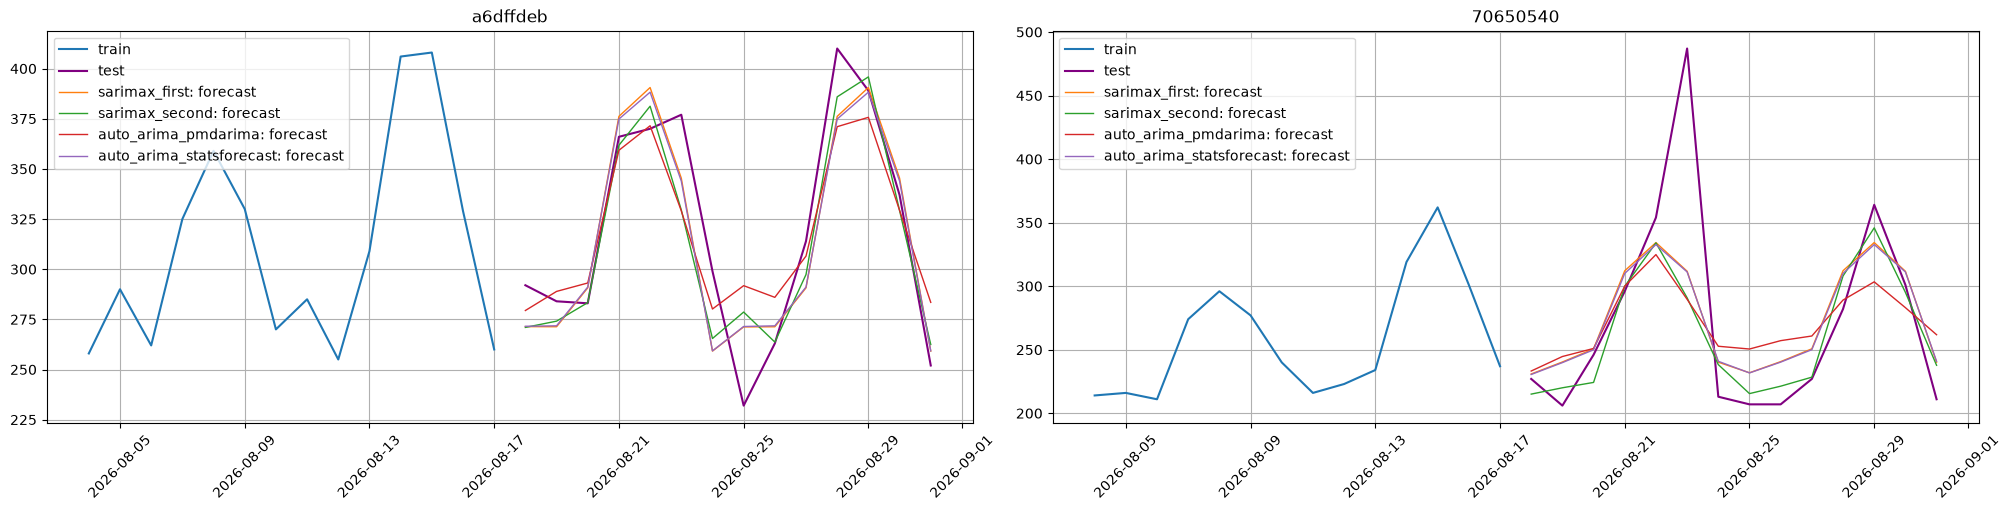

In [79]:
# Прогнозы на одном графике: подход 2 vs подход 3 (baseline не рисуем — он сильно мимо и забьёт масштаб)
plot_forecast(
    forecast_ts={name: forecasts[name] for name in ["sarimax_first", "sarimax_second", "auto_arima_pmdarima", "auto_arima_statsforecast"]},
    test_ts=test_sample_ts,
    train_ts=train_sample_ts,
    n_train_samples=2 * 7,  # последние 6 недель train, чтобы был виден недельный узор
)

**Выводы**

Сплит: train 2026-04-01 … 2026-08-17 (139 дней), test 2026-08-18 … 2026-08-31 (14 дней), 2 юнита.

| Подход | Лучшая модель | `smape_macro` |
|---|---|---|
| 1. baseline | `sarimax_default` — `(1,0,0)`| 36.12 |
| 2. одна конфигурация | `sarimax_second` — `(0,0,1)(1,1,0,7)` | 7.42 |
| 3. автоподбор | `auto_arima_statsforecast` | 8.64 |

**1. Baseline: сезонность решает почти всё.** Без сезонной части SMAPE около 36%, с ней 7–10%. Недельный узор — главное, что нужно уловить в этих данных. Сильнее всего baseline проваливается на `a6dffdeb` (42.8%): у этого юнита самый выраженный недельный узор.

**2. Одна конфигурация: параметры с одного юнита переносятся на похожие.** Параметры подбирались только по графикам `70650540` (Задание 3), но на `a6dffdeb` дали 5.6–6.2%, лучшие цифры в таблице. У юнитов похожая структура ряда, поэтому подход «одна конфигурация на всех» здесь работает.

**3. Автоподбор: два алгоритма, разные результаты.**
- `StatsForecastAutoARIMAModel` выбрал для **обоих** юнитов ровно `(1,0,0)(0,1,1,7)`, то есть наш основной ручной кандидат `first`. Автоматика независимо пришла к тому же выводу, что и ручной разбор ACF/PACF. Небольшая разница в SMAPE с `sarimax_first` (11.16 против 11.23, 6.12 против 6.17) — это разные реализации оценки коэффициентов (statsforecast и statsmodels), а не разные модели.
- `AutoARIMAModel` (pmdarima) выбрал другие модели и оказался худшим среди моделей с сезонностью (10.55). Для `70650540` он взял `(0,0,1)(1,0,0,7)`: это почти `second`, но **без сезонного дифференцирования (`D=0`)**, и SMAPE вырос с 9.22 до 14.46. Значит, для этого ряда `D=1` важен. Причина в том, что pmdarima решает про `D` другим тестом (OCSB, а не ADF), а на 139 точках тесты слабые и легко расходятся. К тому же он примерно в 10 раз медленнее (≈5.6 с против ≈0.6 с).

**4. Оговорка: всё посчитано на одном окне из 14 дней.** Разница между 7.42, 8.64 и 8.70 — около процентного пункта, на другом окне модели могут поменяться местами. Надёжно видно только два различия: baseline намного хуже всех, а модели с `D=0` хуже моделей с `D=1`. Чтобы честно сравнить `first` и `second`, нужен `backtest` на нескольких окнах.

**Итог.**
- Сезонная часть обязательна.
- Ручной подбор по одному юниту переносится на похожие юниты.
- `StatsForecastAutoARIMAModel` воспроизвёл ручной выбор, работает быстро и подходит для масштабирования на 10+ юнитов.
- pmdarima на этих данных хуже и медленнее.


### Бонус. Общая картина по всем 10 юнитам + логирование

1. Прогони лучшее сочетание `order`/`seasonal_order` сразу на всех 10 юнитах (используй `orders_df` из Задания 2 без фильтра по `unit_size`). Учти раздел 1.3 — `fit()` здесь не мгновенный, но на наших объёмах (10 юнитов, дневные данные) всё ещё займёт доли секунды, а не минуты.
2. Посчитай весь набор метрик — `SMAPE`, `WAPE`, `MAPE`, `MAE`, `Bias` (через `src/prod_metrics.py`), per-segment и агрегированно.
3. Собери всё в одну таблицу `result` (`segment`/`unit_size`/`pick_reason`/`total_orders` + все метрики).
4. Залогируй через `log_to_mlflow(...)`, не забудь `tags={"chapter": "ch05", "units_scope": "all_10", "granularity": "day"}` — тогда в MLflow сможешь сравнить со всеми предыдущими моделями прямо в таблице запусков.


In [80]:
# Все 10 юнитов сразу — тот же orders_df из Задания 2 (с 2026-04-01), но без фильтра по unit_size.
# Период и горизонт — как в бонусах NaiveModel / MovingAverageModel / SeasonalMovingAverageModel,
# поэтому метрики в MLflow сравнимы с ними напрямую: test — те же 14 дней 2026-08-18 … 2026-08-31.
orders_ts = TSDataset(orders_df, freq="D")
train_all_ts, test_all_ts = orders_ts.train_test_split(test_size=HORIZON)

print(f"train: {train_all_ts.timestamps.min().date()} … {train_all_ts.timestamps.max().date()} ({len(train_all_ts.timestamps)} дн.)")
print(f"test:  {test_all_ts.timestamps.min().date()} … {test_all_ts.timestamps.max().date()} ({len(test_all_ts.timestamps)} дн.)")
print(f"segments ({len(train_all_ts.segments)}): {train_all_ts.segments}")

train: 2026-04-01 … 2026-08-17 (139 дн.)
test:  2026-08-18 … 2026-08-31 (14 дн.)
segments (10): ['155082de', '3bfb39ef', '70650540', '733e17e8', '8a399130', '9bb64107', 'a5cd0472', 'a6dffdeb', 'aa88e1ec', 'd3319417']


In [81]:
# Кандидаты для бонуса — те же, что в Задании 5, от простого к сложному.
# Модели создаются ЗАНОВО, а не берутся из словаря models(те уже обучены на 2 юнитах).
#
# Для каждой модели храним описание, которое потом уйдёт в MLflow:
#   run_label — имя запуска в MLflow (к нему добавится суффикс _ch05_all_10_day);
#   approach  — подход (тег): baseline / one_config / auto;
#   impl      — реализация (тег): statsmodels / pmdarima / statsforecast;
#   params    — параметры модели (params в MLflow).
def make_bonus_models():
    return {
        # ── Подход 1. Baseline: дефолт без сезонности ───────────────────────────────────────────
        "sarimax_default": {
            "run_label": "SARIMAX_baseline_default",
            "approach": "baseline",
            "impl": "statsmodels",
            "params": {"order": (1, 0, 0), "seasonal_order": (0, 0, 0, 0)},
            "model": SARIMAXModel(),
        },
        # ── Подход 2. Одна ручная конфигурация на ВСЕ 10 юнитов ─────────────────────────────────
        # Параметры подобраны по одному юниту 70650540 (Задание 3). Проверяем, переносятся ли они на
        # юниты других размеров — ожидание, что хуже: паттерны у маленьких и больших юнитов разные.
        "sarimax_first": {
            "run_label": "SARIMAX_one_config_first",
            "approach": "one_config",
            "impl": "statsmodels",
            "params": MODEL_PARAMS["first"],   # (1,0,0)(0,1,1,7)
            "model": SARIMAXModel(**MODEL_PARAMS["first"]),
        },
        "sarimax_second": {
            "run_label": "SARIMAX_one_config_second",
            "approach": "one_config",
            "impl": "statsmodels",
            "params": MODEL_PARAMS["second"],  # (0,0,1)(1,1,0,7)
            "model": SARIMAXModel(**MODEL_PARAMS["second"]),
        },
        # ── Подход 3. Автоподбор: свои порядки для КАЖДОГО юнита ─────────────────────────────────
        # Какие порядки выбраны для каждого юнита — попадёт в таблицу по юнитам (артефакт в MLflow).
        # pmdarima на 10 юнитах заметно медленный (порядка минуты), statsforecast — секунды.
        "auto_arima_pmdarima": {
            "run_label": "SARIMAX_auto_pmdarima",
            "approach": "auto",
            "impl": "pmdarima",
            "params": {"m": 7, "seasonal": True},
            "model": AutoARIMAModel(m=7, seasonal=True),
        },
        "auto_arima_statsforecast": {
            "run_label": "SARIMAX_auto_statsforecast",
            "approach": "auto",
            "impl": "statsforecast",
            "params": {"season_length": 7},
            "model": StatsForecastAutoARIMAModel(season_length=7),
        },
    }

In [82]:
def get_chosen_orders(name, model):
    """Какие order / seasonal_order реально использует модель для каждого юнита: {segment: (order, seasonal_order)}.

    Для SARIMAXModel они одинаковые у всех юнитов (заданы руками), для автоподбора — свои у каждого.
    """
    orders = {}
    for segment, internal in model.get_model().items():
        if name == "auto_arima_statsforecast":
            # statsforecast хранит порядки в model_["arma"] как (p, q, P, Q, s, d, D)
            p, q, P, Q, s, d, D = internal.model_["arma"]
            orders[segment] = ((p, d, q), (P, D, Q, s))
        else:
            # SARIMAXModel и pmdarima отдают statsmodels SARIMAXResultsWrapper
            orders[segment] = (internal.model.order, internal.model.seasonal_order)
    return orders


bonus_models = make_bonus_models()
bonus_runs = {}  # имя модели → всё, что нужно для логирования в MLflow (метрики, таблица по юнитам)

for name, spec in bonus_models.items():
    model = spec["model"]

    started = time.perf_counter()
    model.fit(train_all_ts)
    forecast_ts = model.forecast(train_all_ts.make_future(future_steps=HORIZON))
    fit_sec = time.perf_counter() - started

    # Метрики по каждому юниту — словари {segment: значение}. Тот же набор, что в бонусах прошлых моделей.
    # Внимание: WAPE() из ETNA — доля (0.08), а pooled()/bias() — проценты (8.0). Так было и в прошлых запусках.
    per_segment = {
        "smape": SMAPE()(y_true=test_all_ts, y_pred=forecast_ts),
        "wape": WAPE()(y_true=test_all_ts, y_pred=forecast_ts),
        "mape": MAPE()(y_true=test_all_ts, y_pred=forecast_ts),
        "mae": MAE()(y_true=test_all_ts, y_pred=forecast_ts),
        "bias": bias(y_true=test_all_ts, y_pred=forecast_ts),
    }
    # Агрегаты по всем 10 юнитам — одно число на метрику. Имена — как в прошлых запусках, чтобы графики в MLflow совпали.
    agg = {
        "smape_macro": SMAPE(mode="macro")(y_true=test_all_ts, y_pred=forecast_ts),  # среднее по юнитам
        "mape_macro": MAPE(mode="macro")(y_true=test_all_ts, y_pred=forecast_ts),
        "mae_macro": MAE(mode="macro")(y_true=test_all_ts, y_pred=forecast_ts),
        "wape_pooled": pooled(test_all_ts, forecast_ts, signed=False),  # взвешено по объёму заказов
        "bias_pooled": pooled(test_all_ts, forecast_ts, signed=True),
        "fit_sec": fit_sec,
    }

    # Таблица по юнитам: описание юнита + выбранные порядки + все метрики. В MLflow — артефакт metrics_by_segment.json.
    chosen = get_chosen_orders(name, model)
    result = units_df.copy()
    result["order"] = result["segment"].map(lambda s: str(chosen[s][0]))
    result["seasonal_order"] = result["segment"].map(lambda s: str(chosen[s][1]))
    for metric_name, values in per_segment.items():
        result[metric_name] = result["segment"].map(values)

    bonus_runs[name] = {"spec": spec, "per_segment": per_segment, "agg": agg, "result": result}
    print(f"{name:<26} smape_macro={agg['smape_macro']:6.2f}  wape_pooled={agg['wape_pooled']:6.2f}  fit_sec={fit_sec:5.2f}")

sarimax_default            smape_macro= 39.10  wape_pooled= 32.15  fit_sec= 0.09
sarimax_first              smape_macro= 11.88  wape_pooled=  9.95  fit_sec= 0.39
sarimax_second             smape_macro= 11.34  wape_pooled=  9.37  fit_sec= 0.18
auto_arima_pmdarima        smape_macro= 12.24  wape_pooled= 10.62  fit_sec=53.13
auto_arima_statsforecast   smape_macro= 12.62  wape_pooled= 10.90  fit_sec= 3.35


In [83]:
# Сводка: одна строка на модель, все агрегированные метрики. Порядок строк — от простого к сложному.
# Для сравнения — прошлые модели на тех же 10 юнитах и тех же 14 днях теста (из MLflow):
#   NaiveModel smape_macro 13.92 · MovingAverageModel 15.95 · SeasonalMovingAverageModel 11.72
bonus_summary = pd.DataFrame([
    {"model": name, "approach": run["spec"]["approach"], "impl": run["spec"]["impl"], **run["agg"]}
    for name, run in bonus_runs.items()
]).set_index("model")
bonus_summary["rank"] = bonus_summary["smape_macro"].rank().astype(int)  # 1 — лучшая по smape_macro
bonus_summary.round(2)

,approach,impl,smape_macro,mape_macro,mae_macro,wape_pooled,bias_pooled,fit_sec,rank
model,,,,,,,,,
sarimax_default,baseline,statsmodels,39.10,32.11,49.73,32.15,-30.42,0.09,5
sarimax_first,one_config,statsmodels,11.88,14.85,15.39,9.95,0.74,0.39,2
sarimax_second,one_config,statsmodels,11.34,14.11,14.50,9.37,-2.23,0.18,1
auto_arima_pmdarima,auto,pmdarima,12.24,15.50,16.43,10.62,0.15,53.13,3
auto_arima_statsforecast,auto,statsforecast,12.62,16.06,16.86,10.90,2.04,3.35,4


In [84]:
# SMAPE по каждому юниту × модели — видно, на каких юнитах одна конфигурация проседает, а автоподбор выручает.
# Строки — юниты от крупных к мелким (total_orders), колонки — модели.
smape_by_unit = (
    units_df.set_index("segment")[["unit_size", "pick_reason", "total_orders"]]
    .join(pd.DataFrame({name: run["per_segment"]["smape"] for name, run in bonus_runs.items()}))
    .sort_values("total_orders", ascending=False)
)
smape_by_unit.round(2)

,unit_size,pick_reason,total_orders,sarimax_default,sarimax_first,sarimax_second,auto_arima_pmdarima,auto_arima_statsforecast
segment,,,,,,,,
a6dffdeb,10+,busier (p75),29099,42.80,6.17,5.63,6.65,6.12
70650540,10+,typical (p25),25437,29.45,11.23,9.22,14.46,11.16
aa88e1ec,7–10,busier (p75),19363,21.14,10.90,8.84,10.05,17.37
d3319417,7–10,typical (p25),17464,51.58,8.20,10.49,9.82,8.41
155082de,5–7,busier (p75),13509,23.66,10.78,10.71,10.36,10.76
733e17e8,5–7,typical (p25),12470,42.56,7.40,7.05,8.10,9.05
3bfb39ef,3–5,busier (p75),9530,44.11,10.34,11.16,10.52,10.31
9bb64107,3–5,typical (p25),7888,48.03,10.12,8.32,8.83,8.81
8a399130,<3,busier (p75),5646,24.34,21.68,18.92,18.23,20.47


In [85]:
# Какие порядки выбрал автоподбор для каждого юнита. Сравни с ручной конфигурацией (1,0,0)(0,1,1,7):
# если для многих юнитов выбрано что-то другое — значит, у них действительно другие паттерны.
chosen_orders_all = pd.DataFrame({
    name: bonus_runs[name]["result"].set_index("segment")["order"] + " " + bonus_runs[name]["result"].set_index("segment")["seasonal_order"]
    for name in ["auto_arima_pmdarima", "auto_arima_statsforecast"]
})
units_df.set_index("segment")[["unit_size", "total_orders"]].join(chosen_orders_all).sort_values("total_orders", ascending=False)

,unit_size,total_orders,auto_arima_pmdarima,auto_arima_statsforecast
segment,,,,
a6dffdeb,10+,29099,"(2, 0, 2) (2, 0, 0, 7)","(1, 0, 0) (0, 1, 1, 7)"
70650540,10+,25437,"(0, 0, 1) (1, 0, 0, 7)","(1, 0, 0) (0, 1, 1, 7)"
aa88e1ec,7–10,19363,"(1, 1, 1) (1, 0, 1, 7)","(2, 0, 0) (0, 1, 1, 7)"
d3319417,7–10,17464,"(0, 0, 1) (2, 0, 0, 7)","(1, 0, 0) (0, 1, 1, 7)"
155082de,5–7,13509,"(1, 0, 0) (2, 0, 0, 7)","(1, 0, 0) (0, 1, 1, 7)"
733e17e8,5–7,12470,"(1, 1, 1) (1, 0, 1, 7)","(1, 0, 0) (0, 1, 1, 7)"
3bfb39ef,3–5,9530,"(1, 0, 0) (2, 0, 0, 7)","(1, 0, 0) (0, 1, 1, 7)"
9bb64107,3–5,7888,"(1, 0, 0) (1, 0, 1, 7)","(1, 0, 0) (0, 1, 1, 7)"
8a399130,<3,5646,"(1, 1, 1) (1, 0, 1, 7)","(0, 1, 2) (2, 0, 0, 7)"


In [87]:
# Логируем каждую модель отдельным запуском. Как потом найти их в MLflow UI:
#
#   Имя запуска:  SARIMAX_<подход>_<вариант>_ch05_all_10_day, например SARIMAX_one_config_second_ch05_all_10_day
#                 — читается на графиках рядом с NaiveModel_ch02_all_10_day и остальными.
#   Теги (фильтр в строке поиска UI, например:  tags.approach = "auto"):
#     chapter      = ch05                           — как у прошлых запусков: ch02 / ch03 / ch04 / ch05;
#     units_scope  = all_10, granularity = day      — как у прошлых запусков;
#     model_family = sarimax                        — все SARIMAX-варианты одним фильтром;
#     approach     = baseline / one_config / auto   — подход из Задания 5;
#     impl         = statsmodels / pmdarima / statsforecast — чья реализация внутри.
#   Параметры (params): order / seasonal_order для ручных, m / season_length для автоподбора.
#   Артефакт metrics_by_segment.json: таблица по юнитам, в т.ч. какие порядки выбраны для каждого.
for name, run in bonus_runs.items():
    spec = run["spec"]
    log_to_mlflow(
        model_name=spec["run_label"],
        model_params={**{k: str(v) for k, v in spec["params"].items()}, "horizon": HORIZON},
        metrics=run["agg"],
        metrics_per_segment=run["per_segment"],
        segment_table=run["result"],
        tags={
            "chapter": "ch05",
            "units_scope": "all_10",
            "granularity": "day",
            "model_family": "sarimax",
            "approach": spec["approach"],
            "impl": spec["impl"],
        },
        run_name_suffix="ch05_all_10_day",
    )